# Correlation - Bdls -Uw variables

###################################################################################################################################################################################################
# By: Andres Rodriguez Corcho, Claire Mallard, Sara Polanco, Camilo Montes, Louis Moresi
# The University of Sydney 2026
# Email: andres.rodriguez1@sydney.edu.au
###################################################################################################################################################################################################

In [59]:
# import morphoGrid as morph
import badlands_companion.morphoGrid as morph
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt  
import scipy.signal as signal
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

In [27]:
%matplotlib

Using matplotlib backend: TkAgg


## Load Data


### UW Load Data

In [2]:
#This function check the number of time steps in the specified directory
def getNumSteps(FolderDir,model,DataDir,FileSeed,max_ts=200):
    directory_name = FolderDir+model+DataDir
    Nsteps=0
    for i in range(max_ts):
        #print(FileSeed,i)
        file_name =FileSeed+ str(i) + '.csv'
        try:
            with open(directory_name + file_name, mode = 'r')as file: 
                Nsteps=Nsteps+1
        except FileNotFoundError:
            #print("File not found {0}".format(directory_name + file_name))
            break
    return Nsteps

#getNumSteps(FolderDir,model,DataDir ,FileSeed)
#getNumSteps(dataFT, "HighEro",'/EroDepo_Evolution_/','eroD_evo_')
#getNumSteps(dataFT,"HighEro", '/Correlation/' ,'0km_slice_')

import csv
import numpy as np
def compute_UwVar(FolderDir, model,FileSeed,Uw_var,
                  maxX,minX,
                  step_time=0.2,total_ts=200):
    
     #maximum possible number of steps
    DataDir='/Correlation/' 
    directory_name = FolderDir+model+DataDir#path to paraView output
    #total_ts = total_steps
    ts_interval = step_time
    #yaxis_label_interval = ts_interval*10
    #-------------------------#
    #functions to get data    # 
    #-------------------------#
    #precision = 0.5 #km
    #print(getNumSteps(FolderDir, FileBase,total_ts))
    
    #######################################################
    # this counts the number of files in the directoty - do not matter about the structure
    #print(FolderDir,model, FileSeed,total_ts)
    num_of_dataFile = getNumSteps(FolderDir,model,DataDir ,FileSeed,total_ts)
    #######################################################
    
    
    #This "cuts" the time of the plot to make it match with other values in the subplot
#     if num_of_dataFile >maxStep:
#         num_of_dataFile=maxStep
    
    model_width_ls = int(np.abs(maxX-minX)) #width of the slice
    #print(maxX,minX)
    #time_ls = 0 #last timestep read 
    #strainID_raw = [] #list of strain rate values 
    
    uwData=np.zeros((num_of_dataFile,model_width_ls)) #Numpy array which will be ploted using imshow
    #xIDs=[] # Xs IDs of the data
    
    #Ratio between number of data per time and 512 which is the model length.A not integer ratio means that there are less than
    #values in one time step
    #lens=[]
    
    #########################################################################################################
    #Actual num_dataFile
    TotalData=num_of_dataFile
    #go through all .csv files
    Nsteps=0
    for i in range(num_of_dataFile):
        file_name =FileSeed+ str(i) + '.csv'
        
        uw_aux=[]
        uw_x_aux=[]  
        #print(file_name)
        try:
            with open(directory_name + file_name, mode = 'r')as file: #Open .csv file with i time step
                reader = csv.DictReader(file)
                ct = 0 #regular counter to loop in all rows
                #record all Uw values (eg. strain rate) along the slice
                for row in reader:
                          
                    
                    try:
                        
                        ###################################
                        ##### DATA AND X POSITIONS OF CURRENT TIME STEP-FILE
                        uw_aux.append(float(row[Uw_var]))
                        uw_x_aux.append(float(row['Points:0']))
                        
                        #print(uw_aux)
                        
                        #print(len(row["strainRateField"]))
                    except KeyError:
                        #print("error_"+str(i))
                        TotalData=TotalData-1
                        break
                    ct +=1 
                
#                 if(i == 1):
#                     model_width_ls = float(ct)
                    
        except FileNotFoundError:
            #print("File not found {0}".format(file_name))
            break
            
#         if(i == num_of_dataFile-1):
#             time_ls = i
          #AFTER ALL ROWS OF THE FILE ARE READ
        #print(uw_x_aux,uw_aux,ct)
        
        
        
    #########################################################################################################
        uw_aux=np.array(uw_aux)
        uw_x_aux=np.array(uw_x_aux)

        #print(uw_x_aux[1]>=minX)

        #Cut=np.where(np.logical_and(uw_x_aux[:]>=minX,uw_x_aux[:]<=maxX))[0]

         #Interpolated arrays time x 512 (Match UW grid)
        #Xnew = np.linspace(0, Cmodel_width_ls*1000,int(Cmodel_width_ls))
        
        ## INTERPOLATION FUNCTION FOR THE UW VARIABLE IN FUNCTION OF THE X COORDINATES
        f = interpolate.interp1d(uw_x_aux, uw_aux,kind="linear")  
         ### INTERPOLATE VARIABLES WITHIN THE SELECTED X INTERVAL
        Xnew = np.linspace(minX, maxX,int(model_width_ls))
        uW_new = f(Xnew)
        
        #print(ct,model_width_ls,Nsteps)
        ###################################
        ## ADD TO ARRAY
        uwData[Nsteps]=uW_new
        
        Nsteps=Nsteps+1

    ##########################
    ## THIS REVERSES THE ARRAY IN STRATIGRAPHIC ORDER
    uwData = uwData[::-1]
    ##########################
    #uwData = np.array(uwData, dtype= float) #conversion into numpy array
    
    #try:
    Min=np.amin(uwData)
    Max=np.amax(uwData)
        
    #except ValueError:
        #print("File not found")
        #pass
    
    return uwData,model_width_ls,Nsteps,Min,Max

#compute_UwVar(dataFT, model,Fbase1,"strainRateField",maxX,minX)
#compute_UwVar(dataFT, "HighEro",'0km_slice_',"strainRateField",600.,-400.)
#np.amax(m[0])

In [383]:
compute_UwVar(dataFT, "HighEro",'4_5km_slice_',"strainRateField",600.,-400.)

(array([[1.33260000e-15, 1.27188929e-15, 1.21117858e-15, ...,
         3.13875846e-17, 3.18452923e-17, 3.23030000e-17],
        [8.69040000e-16, 7.49040000e-16, 6.29040000e-16, ...,
         3.47580250e-17, 3.52455125e-17, 3.57330000e-17],
        [2.88820000e-16, 2.90756937e-16, 2.92693874e-16, ...,
         3.45537528e-17, 3.49273764e-17, 3.53010000e-17],
        ...,
        [1.44400000e-16, 1.46674775e-16, 1.48949550e-16, ...,
         4.15844204e-17, 4.13742102e-17, 4.11640000e-17],
        [2.02320000e-16, 2.06258939e-16, 2.10197878e-16, ...,
         6.78995105e-17, 6.68942553e-17, 6.58890000e-17],
        [1.00000000e-15, 1.00000000e-15, 1.00000000e-15, ...,
         1.00000000e-15, 1.00000000e-15, 1.00000000e-15]]),
 1000,
 200,
 9.56518118118119e-19,
 6.750715315315315e-14)

### Load bdls data

In [165]:


#This funcion loads all Bdls slices from an specified directoy, then interpolates them to match the size of the UW
#slices data, finally exports a numpy array which can be used do visualize the EroDepo evolution
import csv
import numpy as np
from scipy import interpolate
def compute_EroDepo_Elev(FolderDir, model,FileSeed="eroD_evo_",maxX=None,minX=None,step_time=0.2,total_ts=200):
    #total_ts = total_steps
    ts_interval = step_time
    
    #yaxis_label_interval = ts_interval*10
    
    #-------------------------#
    #functions to get data    # 
    #-------------------------#
    #######################################################
    DataDir='/EroDepo_Evolution_/' 
    directory_name = FolderDir+model+DataDir #path to paraView output
    # this counts the number of files in the directoty - do not matter about the structure
    num_of_dataFile = getNumSteps(FolderDir,model,DataDir, FileSeed,total_ts)
    #######################################################
    
    Cmodel_width_ls=int(np.abs(maxX-minX)) #width of the slice
    
    #model_width_ls = 0 #width of the slice
    #time_ls = 0 #last timestep read 
    
    EroDepoData=np.zeros((num_of_dataFile,Cmodel_width_ls)) #Numpy array which will be ploted using imshow
    ElevationData=np.zeros((num_of_dataFile,Cmodel_width_ls)) #Numpy array which will be ploted using imshow
    
    #EroDepo_raw = [] #list of EroDepo values from badlands surface
    #X_coords_raw = [] #list of EroDepo values (X coordinate) from badlands surface
    #Elev_raw = [] #List of Elevation values from badlands surface
    
    
    avrElev=np.array([]) #list with average elevations
    

    #Actual num_dataFile
    TotalData=num_of_dataFile
    #go through all .csv files
    
    Nsteps=0
    
    for i in range(num_of_dataFile):

        file_name =FileSeed+ str(i) + '.csv'
        #file_name =FileSeed+'_' + str(i) + '.csv'
        
        auxEroDepo=[]
        auxElev=[]
        #auxSlvl=[]
        auxX_coord=[]
        
        #print(file_name)
        #print(i)
        try:
            with open(directory_name + file_name, mode = 'r')as file: #Open .csv file with i time step
                reader = csv.DictReader(file)
                ct = 0 #regular counter to loop in all rows
                #record all strain rate values along the slice
                for row in reader:
                    
                    try:
                        #Raw data from Badlands surface
                        auxEroDepo.append(float(row["EroDep"]))
                        auxX_coord.append(float(row["Points:0"]))
                        auxElev.append(float(row["Elevation"]))
                        #auxSlvl.append(float(row["Sealevel"]))
                    except KeyError:
                        print("error_"+str(i))
                        TotalData=TotalData-1
                        break
                    ct +=1 
                
                #Making numpy arrays
                auxEroDepo=np.array(auxEroDepo)
                auxX_coord=np.array(auxX_coord) #THIS IS IN METERS
                auxElev=np.array(auxElev)
                
                #print(auxX_coord)
                #print(max(auxEroDepo))
                #Interpolation Ero-Depo 
                f = interpolate.interp1d(auxX_coord/1e3, auxEroDepo,kind="linear")  
                #Interpolation Elevation
                fElev= interpolate.interp1d(auxX_coord/1e3, auxElev,kind="linear")
                
                
                #Interpolated arrays time x 512 (Match UW grid)
                #Xnew = np.linspace(0, Cmodel_width_ls*1000,int(Cmodel_width_ls))
                #uW_new = f(Xnew)
                
                ############################################################
                ### INTERPOLATE VARIABLES WITHIN THE SELECTED X INTERVAL
                Xnew = np.linspace(minX, maxX,int(Cmodel_width_ls)) ###XMIN AND XMAX ARE IN KMS
                EroDepo_new = f(Xnew)
                Elev_new = fElev(Xnew)
                ############################################################
                
                #print(EroDepo_new )
                
                #Mean of elevation
                #AuxavrElev=np.mean(auxElev)
                #add to big list the average elevation of the current time
                #avrElev=np.append(avrElev,[AuxavrElev])
                
                #Add to big list the interpolated values
#                 if i==0:
#                     EroDepo_raw.append(EroDepo_new)  
#                     X_coords_raw.append(Xnew)
#                     Elev_raw.append(Elev_new)
#                 else:
#                     EroDepo_raw[0]=np.append(EroDepo_raw[0],[EroDepo_new])
#                     X_coords_raw[0]=np.append(X_coords_raw[0],[Xnew])
#                     Elev_raw[0]=np.append(Elev_raw[0],[Elev_new])
                        
        except FileNotFoundError:
            #print("File not found {0}".format(file_name))
            break

#         if(i == num_of_dataFile-1):
#             time_ls = i

        #### ADDING DATA TO THE BIG NUMPY ARRAY
        EroDepoData[Nsteps]=EroDepo_new 
        ElevationData[Nsteps]=Elev_new
        
        #print(max(EroDepo_new ))
        
        Nsteps=Nsteps+1
    
    #TotalData=ct      
    #print(TotalData)
    ##########################
    #time = time_ls 
    #print(num_of_dataFile)
#     model_width_ls = Cmodel_width_ls #km


    #print("Ero-Depo loaded")
#     print(TotalData,model_width_ls)
    #print((EroDepo_raw))
    
    #print(EroDepoData)
    
    try:
        Min=np.amin(EroDepoData)
        Max=np.amax(EroDepoData)
        
        MinEl=np.amin(ElevationData)
        MaxEl=np.amax(ElevationData)
        
    except ValueError:
        #print("File not found")
        pass
    
    #EroDepo = np.reshape(EroDepo_raw, (TotalData, int(Cmodel_width_ls))) #reshape the array
    #Elevation = np.reshape(Elev_raw, (TotalData, int(Cmodel_width_ls))) #reshape the array
    
    #Elevation = np.array(Elevation, dtype= float)
    #EroDepo = np.array(EroDepo, dtype= float)
    
    #EroDepo = EroDepo[::-1]
    #Elevation = Elevation[::-1]
    ###############################
    ## THIS REVERSES THE ARRAY IN STRATIGRAPHIC ORDER
    EroDepoData = EroDepoData[::-1]
    ElevationData = ElevationData[::-1]
    ###############################
    #return 0
    return EroDepoData,Nsteps,Min,Max,ElevationData,MinEl,MaxEl
    

#compute_EroDepo_Elev(FolderDir, model,FileBase,maxX,minX,step_time=0.2,total_ts=600)
#compute_EroDepo_Elev(dataFT, "HighEro","eroD_evo_",1300.,-1300.)
#compute_EroDepo_Elev(dataFT, "MedEro","eroD_evo_",600.,-400.)
#return EroDepoData,Nsteps,Min,Max,ElevationData,MinEl,MaxEl

In [393]:
#This function calculates the strain_rate difference and receive as parameter the two strain_rate slices to substract
def uw_SubstractionDirectData(uw1,uw2):
    
    max1=len(uw1)
    max2=len(uw2)
    #print(max1,max2)
    NSteps=0
    
    if max1>max2:
        NSteps=max2
        subs_shape=np.shape(uw2)
    else:
        NSteps=max1
        subs_shape=np.shape(uw1)
        
    
    subs=np.zeros(subs_shape)
    total_ts=NSteps
    #len(subs[0])
    
    for i in range(0,NSteps):
        counter=0
        #print(i)
        #for m,n in zip (strain1[0],strain2[1]):
        for k in range(0,len(subs[0])):
            #print(k)
            try:
                auxSubstraction=uw1[i][k]-uw2[i][k]
                subs[i][k]=auxSubstraction
                #counter=counter+1
            except IndexError:
                #break
                pass
    uwID=subs
    return uwID,total_ts

#Get data from strain_rate slices from the Bdls and noBdls models. Also calculates the strain_rate difference 
#between the two
def getUw_data(FolderDir, model,modelRef,depth_cross_section,uWvar,maxX,minX,total_ts,step_time= 0.2):
    
    #Uw_var
    seed=depth_cross_section+"_slice_"
    #print(seed)
    #compute_UwVar(dataFT, "HighEro",'0km_slice_',"strainRateField",600.,-400.)
    # return model_width_ls,Nsteps,Min,Max
    
    UwData,model_width_ls,total_s1,Min,Max=compute_UwVar(FolderDir,model,seed,uWvar, maxX,minX,total_ts=total_ts)
    
    #Strain noBdls
    UwData_ref,model_width_ls,total_s2,MinR,MaxR=compute_UwVar(FolderDir,modelRef,seed,uWvar,maxX,minX,
                                                               total_ts=total_ts)
    #Compute difference - to doooo
    substraction,total_ts=uw_SubstractionDirectData(UwData,UwData_ref)
    
    ###############################################################################################

    #Compute difference
    #substraction,total_ts=strain_rate_SubstractionDirectData(strain1,strain2)
    
    return UwData,UwData_ref,substraction,total_ts,model_width_ls

#getUw_data(FolderDir, model,modelRef,depth_cross_section,uWvar,maxX,minX,step_time= 0.2)
#getUw_data(dataFT,"HighEro","NoEro",'0km',"strainRateField",600.,-400.)
#return UwData,UwData_ref,substraction,total_ts,model_width_ls

In [394]:
getUw_data(dataFT,"HighEro","NoEro",'4_5km',"strainRateField",600.,-400.,total_ts=175)#

(array([[1.05770000e-15, 1.18935666e-15, 1.32101331e-15, ...,
         7.05001942e-17, 7.09030971e-17, 7.13060000e-17],
        [1.86660000e-15, 1.90916757e-15, 1.95173514e-15, ...,
         6.89090110e-17, 6.89035055e-17, 6.88980000e-17],
        [1.96590000e-15, 1.70889299e-15, 1.45188599e-15, ...,
         8.12672122e-17, 8.11611061e-17, 8.10550000e-17],
        ...,
        [1.44400000e-16, 1.46674775e-16, 1.48949550e-16, ...,
         4.15844204e-17, 4.13742102e-17, 4.11640000e-17],
        [2.02320000e-16, 2.06258939e-16, 2.10197878e-16, ...,
         6.78995105e-17, 6.68942553e-17, 6.58890000e-17],
        [1.00000000e-15, 1.00000000e-15, 1.00000000e-15, ...,
         1.00000000e-15, 1.00000000e-15, 1.00000000e-15]]),
 array([[9.08170000e-16, 9.42987317e-16, 9.77804635e-16, ...,
         5.40234915e-17, 5.42777457e-17, 5.45320000e-17],
        [1.34760000e-15, 1.54256997e-15, 1.73753994e-15, ...,
         5.21146416e-17, 5.25438208e-17, 5.29730000e-17],
        [2.00050000e-15, 

In [5]:


#This function look all the Bdls and noBdls strain_rate and find the Min, Max for all time steps
def getMinMaxUw(strains):
    ct=0
    for i in strains:
        for k in i:
            auxMin=min(k)
            auxMax=max(k)
            if ct>0:
                if auxMin<Min:
                    Min=auxMin
                    if Min<0:
                        Min=Min#0
                if auxMax>Max:
                    Max=auxMax
            else:
                Max=auxMax
                Min=auxMin
            ct=ct+1
        
    return Min,Max

#This function look all the Bdls and noBdls strain_rate and find the Min, Max for just one time step
def getMinMaxUw_single(strains):
    ct=0
    for i in strains:
        auxMin=min(i)
        auxMax=max(i)
        if ct>0:
            if auxMin<Min:
                Min=auxMin
                if Min<0:
                    Min=Min#0
            if auxMax>Max:
                Max=auxMax
        else:
            Max=auxMax
            Min=auxMin
        ct=ct+1
    return Min, Max


def filterZero(tickLabels):
    filtered=np.array([])
    for i in tickLabels:
        if i!=0:
            filtered=np.append(filtered,[i])
    return filtered

#This functions are used to enable the subplots function to decide what to put into the spaces of the subplots 
#depending of a "keyname" variable
def isUw(keyName):
    ans=False
    if keyName=="Bdls" or keyName=="noBdls" or keyName=="Diff":
        ans=True
    return ans

def isEroDepo(keyName):
    ans=False
    if keyName=="EroDepo":
        ans=True
    return ans

def isElev(keyName):
    ans=False
    if keyName=="Elev":
        ans=True
    return ans

def isSlvl(keyName):
    ans=False
    if keyName=="Slvl":
        ans=True
    return ans

#This function tell the subplot function what to plot in the spaces of the subplot
def getDataType(key,uw1,uw2,uwdiff,eroD,EleV):
    if key=="Bdls":
        data=uw1
        label="Strain rate Bdls"
    elif key=="noBdls":
        data=uw2
        label="Strain rate noBdls"
    elif key=="Diff":
        data=uwdiff
        label="Strain rate Difference Bdls - noBdls"
    elif key=="EroDepo":
        data=eroD
        label="Erosion-Deposition"
    elif key=="Slvl":
        label="Sea Level"
    elif key=="Elev":
        label="Elevation"
        data=EleV
    return data,label

#This function loads the .slvl .csv file used to run the coupled models
import pandas as pd
def getSlvl(filename):
    data=pd.read_csv(filename,header=None,delimiter=r"\s+",names=["Time", "Slvl"])
    #print(data)
    t=data[['Time']].to_numpy()
    Slvl=data[['Slvl']].to_numpy()
    
    return Slvl,t

#This function finds in a SLvl curve the depth of the first transgression given the time this transgression occurs
def getRefTransgression(realSlvl,t,t_transg):
    counter=0
    for i,j in zip(realSlvl,t):
        #print(np.round(j,1))
        if np.round(j,1)==t_transg:
            ref=realSlvl[counter]
            break
        counter=counter+1
    return ref

## Correlation functions

In [497]:
def prepareCorrelationPlot(filter_index, corr_data,dt=5):
    
    time=[]
    corr=[]
    
    time_local=0
    
    for corr_time in corr_data:
        time.append(time_local)
        corr.append(corr_time.iloc[filter_index])
        
        time_local=time_local+dt
        
    return np.array(time),np.array(corr)

def prepareNdataPlot(model,depth, Ncorr_data,dt=5):
    
    time=[]
    Ndata=[]
    
    time_local=0
    
    name=model+"_"+depth
    
    for N_time in Ncorr_data:
        time.append(time_local)
    
        d_framesNa = N_time[name]
        total=np.sum(np.array(d_framesNa ))
        Ndata.append(total)
        #Ndata.append(N_time.iloc[filter_index])
        
        time_local=time_local+dt
        
    return np.array(time),np.array(Ndata)


#Filters correlation data by a N value. if there is less than N, correlation is set to zero.
def filterbyN(data_array,N_data_array,N_thres=80,nans=False):
    
    filtered_data=np.zeros(len(data_array))
    
    ct=0
    for data_s, N_data in zip (data_array,N_data_array):
        
        if N_data >=N_thres:
            filtered_data[ct]=data_s
        else:
            #filtered_data[ct]=np.nan
            if nans==True:
                filtered_data[ct]=np.nan
            else:
                filtered_data[ct]=0.
        ct=ct+1
        
    return filtered_data

In [198]:
def getAvg_uw_eroDepo_vs_time_vars_all(FolderDir,
                                           sT1,
                                           pSt1,
                                           DevX1,
                                           DevY1,
                                           Uw1_v,
                                           EroDepo,
                                              bdls_thresh_i,
                                               bdls_thresh_f,
                                               start_time,
                                               final_time,
                                               propFilter=False,   
                                               propThres_i=None,
                                               propThres_f=None,
                                               propVar="strainRateField",
                                               stepT=0.2):
    
    #timeStep=int(time_Ma/stepT) #Time to interrogate from array 2D
    #=36. #In this case, the compute functions below already are cut to 36 Myr - paper 2
    
    times=np.array([])

    ## Arrays where data will be saved
    ##Strain rate
    All_sT1=np.array([])
    Ndata_sT1=np.array([]) #number of data
    
    #Plastic strain
    All_pSt1=np.array([])
    Ndata_pSt1=np.array([]) #number of data
    ############### Separate Stress tensors in negative and positive values
    #Tensor XX
    All_DevX1_P=np.array([])
    All_DevX1_N=np.array([])
    Ndata_DevX1_P=np.array([]) #number of data
    Ndata_DevX1_N=np.array([]) #number of data
    
    #Tensor YY
    All_DevY1_P=np.array([])
    All_DevY1_N=np.array([])
    Ndata_DevY1_P=np.array([]) #number of data
    Ndata_DevY1_N=np.array([]) #number of data
    
    #Bdls data
    All_Bdls=np.array([]) #Ero or Depo bdls data _ specified as input
    Ndata_Bdls=np.array([])
     ###############  ###############  ###############  ###############  ###############  ############### 
    
    #############
    
    #####LOOP INTO TIMES TO CALCULATE AVG
    ## In this case, just loop the times we need
    
    step_0=int(start_time/stepT)
    step_f=int(final_time/stepT)
    
    #for timeStep in range(0,np.shape(sT1)[0]):
    

    
    #This below stack data whithin a timeframe
    for timeStep in range(step_0,step_f):
        #print(model,timeStep,timeStep*0.2)
        CurrentTime=timeStep*stepT
        ###########################################################################
        ##Sliced data _Uw variables
        sT1_varSlice=sT1[timeStep] #strain rate
        pSt1_varSlice=pSt1[timeStep] #Plastic strain
        DevX1_varSlice=DevX1[timeStep] #Dev Tensor XX
        DevY1_varSlice=DevY1[timeStep] #Dev Tensor YY
        #uw_noEroSlice=Uw2[timeStep]
        #Filtered normalized strain or plastic strain
        Uw1_v_normSlice=Uw1_v[timeStep]
        
        #Bdls slice
        EroDepoSlice=EroDepo[timeStep]
        #EvelSlice=Elevation1[timeStep]
        #####################################################################################
        
        # bdls_thresh in meters
        # Filtering ero-depo
        if bdls_thresh_i>0: 
            #print("deposition threshold")
            #print("fuckkk")
            #print((EroDepoSlice))
            cond0=np.where(np.logical_and(EroDepoSlice[:]>=bdls_thresh_i,
                                   EroDepoSlice[:]<=bdls_thresh_f))[0]  #The condition depends on the deposition
            #print("bdls filter")
            #print(cond0)
        elif bdls_thresh_i<0:
            #print("erosion threshold")
            cond0=np.where(np.logical_and(EroDepoSlice[:]<=bdls_thresh_i,
                                   EroDepoSlice[:]>=bdls_thresh_f))[0] #The condition depends on the erosion
        
        #Filtering by proportion
        if propFilter==True:
            if propThres_i>0:
                #print("Proportion Filter!")
                #print(len(Uw1_v_normSlice),len(EroDepoSlice),len(pSt1_varSlice),len(cond0))
                condF=np.where(np.logical_and(Uw1_v_normSlice[cond0]>=propThres_i,
                                             Uw1_v_normSlice[cond0]<propThres_f))[0]
                #print("UWnorm filter")
                #print(condF)
            elif propThres_i<0:
                #print("negative prop")
                condF=np.where(np.logical_and(Uw1_v_normSlice[cond0]<=propThres_i,
                                             Uw1_v_normSlice[cond0]>propThres_f))[0]
            cond=cond0
        else:
            cond=cond0
        #######################################################
        ## Calculate average over threshold in Bdls Ero or Depo
        #######################################################
        ###Initialize slices in case there is a nan
        sT1_thresh_slice=0.
        pSt1_thresh_slice=0.
        DevX1_thresh_slice_P=0.
        DevX1_thresh_slice_N=0.
        DevY1_thresh_slice_P=0.
        DevY1_thresh_slice_N=0.
        
        if propFilter==True:
            ## Strain rate
            sT1_thresh_slice=sT1_varSlice[cond][condF]
            ## Plastic strain
            pSt1_thresh_slice=pSt1_varSlice[cond][condF]
            ## Dev XX tensor
            DevX1_thresh_slice=DevX1_varSlice[cond][condF]
            DevX1_thresh_slice_P=DevX1_thresh_slice[DevX1_thresh_slice>0]
            DevX1_thresh_slice_N=DevX1_thresh_slice[DevX1_thresh_slice<0]
            ## Dev YY tensor
            DevY1_thresh_slice=DevY1_varSlice[cond][condF]
            DevY1_thresh_slice_P=DevY1_thresh_slice[DevY1_thresh_slice>0]
            DevY1_thresh_slice_N=DevY1_thresh_slice[DevY1_thresh_slice<0]
            #Bdls
            bdls_slice=EroDepoSlice[cond][condF]
        else:
            ## Strain rate
            sT1_thresh_slice=sT1_varSlice[cond]
            ## Plastic strain
            pSt1_thresh_slice=pSt1_varSlice[cond]
            ## Dev XX tensor
            DevX1_thresh_slice=DevX1_varSlice[cond]
            DevX1_thresh_slice_P=DevX1_thresh_slice[DevX1_thresh_slice>0]
            DevX1_thresh_slice_N=DevX1_thresh_slice[DevX1_thresh_slice<0]
            ## Dev YY tensor
            DevY1_thresh_slice=DevY1_varSlice[cond]
            DevY1_thresh_slice_P=DevY1_thresh_slice[DevY1_thresh_slice>0]
            DevY1_thresh_slice_N=DevY1_thresh_slice[DevY1_thresh_slice<0]
            #Bdls
            bdls_slice=EroDepoSlice[cond]
        
        ##### Counting how much data in AVG estimatios
        
        #Strain_rate
        Ndata_sT1=np.append(Ndata_sT1,len(sT1_thresh_slice))
        ## Plastic strain
        Ndata_pSt1=np.append(Ndata_pSt1,len(pSt1_thresh_slice))
        ## Dev XX tensor
        Ndata_DevX1_P=np.append(Ndata_DevX1_P,len(DevX1_thresh_slice_P))
        Ndata_DevX1_N=np.append(Ndata_DevX1_N,len(DevX1_thresh_slice_N))
        ## Dev YY tensor
        Ndata_DevY1_P=np.append(Ndata_DevY1_P,len(DevY1_thresh_slice_P))
        Ndata_DevY1_N=np.append(Ndata_DevY1_N,len(DevY1_thresh_slice_N))
        #Bdls ero or depo
        Ndata_Bdls=np.append(Ndata_Bdls,[len(bdls_slice)])
    
        times=np.append(times,[CurrentTime])
        
        #d=np.hstack([d,a])
        
        All_sT1=np.hstack([All_sT1,sT1_thresh_slice])
        All_pSt1=np.hstack([All_pSt1,pSt1_thresh_slice])
        All_DevX1_P=np.hstack([All_DevX1_P,DevX1_thresh_slice_P]) 
        All_DevX1_N=np.hstack([All_DevX1_N,DevX1_thresh_slice_N])
        All_DevY1_P=np.hstack([All_DevY1_P,DevY1_thresh_slice_P])
        All_DevY1_N=np.hstack([All_DevY1_N,DevY1_thresh_slice_N])
        All_Bdls=np.hstack([All_Bdls,bdls_slice])
        
        while len(All_DevX1_P)<len(All_sT1):
            All_DevX1_P=np.append(All_DevX1_P,[np.nan])
        while len(All_DevX1_N)<len(All_sT1):
            All_DevX1_N=np.append(All_DevX1_N,[np.nan])
        while len(All_DevY1_P)<len(All_sT1):
            All_DevY1_P=np.append(All_DevY1_P,[np.nan])
        while len(All_DevY1_N)<len(All_sT1):
            All_DevY1_N=np.append(All_DevY1_N,[np.nan])

    return (times, #0
            (All_sT1,Ndata_sT1), #1
            (All_pSt1,Ndata_pSt1), #2
            (All_DevX1_P,Ndata_DevX1_P), #3
            (All_DevX1_N,Ndata_DevX1_N), #4
            (All_DevY1_P,Ndata_DevY1_P), #5
            (All_DevY1_N,Ndata_DevY1_N),  #6
            (All_Bdls,Ndata_Bdls), #7
            #(), #8
           ) 
    #return times,Avgs_uw_P,Avgs_uw_N
    ## return a tuple for each variable (in total 4), with positive /negative data and the number of values
    #return uw_varSlice,uw_noEroSlice,EroDepoSlice, EvelSlice
    
    # t,Avgs_uw_P,Avgs_uw_N=getAvg_uw_eroDepo_vs_time_double(dataFT, "HighEro",'3km','projStressTensor:0',650., -100.,36,
#                                               Thres,stepT=0.2)

In [194]:
#Function to get correlation data for all time steps of a selected model.


def getCorrelationStages_model_all(FolderDir,
                         model,
                         depth,
                         maxX,minX,
                         bdls_thresh_i,
                         bdls_thresh_f,
                         propFilter=False,   
                       propThres_i=None,
                       propThres_f=None,
                       propVar="strainRateField",
                         max_time=35., #maximum time used to compute the stages
                         time_interval_cut=5., #the time span of each interval to get correlation
                         t_step=0.2,
                         correlation='pearson',
                        bdls_source="eroD_evo_",
                        ):
    
      # I need one of the below each 5 Myr
#     df_stack_pre=pd.DataFrame({})
#     df_stack_syn=pd.DataFrame({})
#     df_stack_post=pd.DataFrame({})
    max_timeStep=int(max_time/t_step) #Max time included in the array 2D
    ##########################################################################################
    #### Get data for each desired UW variable
    
    #Strain rate
    sT1,sT2,sTdif,total_ts,Cmodel_width_ls=getUw_data(FolderDir, model,"NoEro",depth,'strainRateField',
                                                 maxX,minX,total_ts=max_timeStep)
    
    #Plastic strain
    pSt1,pSt2,pStdif,total_ts,Cmodel_width_ls=getUw_data(FolderDir, model,"NoEro",depth,'projPlasticStrain',
                                                 maxX,minX,total_ts=max_timeStep)
    
    
    #Deviatoric XX
    DevX1,DevX2,DevXdif,total_ts,Cmodel_width_ls=getUw_data(FolderDir, model,"NoEro",depth,'projStressTensor:0',
                                                 maxX,minX,total_ts=max_timeStep)
    
    #Deviatoric YY
    DevY1,DevY2,DevYdif,total_ts,Cmodel_width_ls=getUw_data(FolderDir, model,"NoEro",depth,'projStressTensor:1',
                                                 maxX,minX,total_ts=max_timeStep)
    
#     #Get Normalized data 
#     DevY1,DevY2,DevYdif,total_ts,Cmodel_width_ls=getUw_data_norm(FolderDir, model,"NoEro",depth,'projStressTensor:1',
#                                                  maxX,minX,total_ts=max_timeStep)
    
    
    ########################################################################################################
    #This get the normalized version of some Uw_variable
    #"strainRateField"
#     Uw1_v,Uw2_v,Uwdif_v,total_ts,Cmodel_width_ls=getUw_data_norm(FolderDir, model,"NoEro",depth,propVar,
#                                                          maxX,minX,total_ts=max_timeStep)
    ########################################################################################################
    Uw1_v,Uw2_v,Uwdif_v,total_ts,Cmodel_width_ls=getUw_data(FolderDir, model,"NoEro",depth,propVar,
                                                         maxX,minX,total_ts=max_timeStep)
    
    ########################################################################################################
    #Uw_dataS=[Uw1,Uw2,Uwdif]
    
    
    ##########################################################################################
    ### Get the bdls data
    #Extract Ero-Depo for deciding min-max of all different models to include in the subplot
    eroDepo1,BdlsSteps1,MinEro1,MaxEro1,Elevation1,MinEl1,MaxEl1=compute_EroDepo_Elev(FolderDir,
                                                    model,bdls_source,
                                                    maxX,minX,total_ts=max_timeStep)

    ##########################################################################################
    
    #Inverting data to start from 0 Myr
    #print(Uw1[0])
    sT1=sT1[::-1] #strain rate
    pSt1=pSt1[::-1] #plastic strain
    DevX1=DevX1[::-1] #Deviatoric X
    DevY1=DevY1[::-1] #Deviatoric Y
    ###Inverting bdls data
    eroDepo1=eroDepo1[::-1]
    Elevation1=Elevation1[::-1]
    #Inverting proportion filter - Strain rate as default
    Uw1_v=Uw1_v[::-1]
    
    times=np.array([])
    
    ###############  ###############  ###############  ###############  ###############  ############### 

    #stages=[7.5,17,36]
    #stages=np.linspace(0,36,(36*2)+1)
    stages=np.linspace(0,max_time,(max_time/time_interval_cut)+1)

     #> 0.6 is good
    stgs_ct=0
    #for model in models: #iterate all selected models
    #for stage in stages:
    df_stages=pd.DataFrame({})
    
    all_dataframes=[]
    all_dataframesN=[]
    all_correlations_times=[] #one every time interval
    time_stage=[]    

    
    for k in range(1,len(stages)):
    #for time in times:
        final_limit=stages[k]
        init_limit=stages[k-1]
        ##################################################################################################
        ############# Getting data - this time data comes in an specific time interval
        ## All data from a selected time interval is contained in an horizontal numpy array
        # The idea is to perform a very big correlation! with all data and no averages
        times,sT,PsT,DevXP,DevXN,DevYP,DevYN,bdls_d=getAvg_uw_eroDepo_vs_time_vars_all(FolderDir,
                                                sT1,
                                                pSt1,
                                                DevX1,
                                                DevY1,
                                                Uw1_v,
                                               eroDepo1,
                                              bdls_thresh_i,
                                               bdls_thresh_f,
                                                start_time=init_limit, ######
                                                final_time=final_limit, ######
                                               propFilter=propFilter,   
                                               propThres_i=propThres_i,
                                               propThres_f=propThres_f,
                                               propVar=propVar,                                    
                                               stepT=0.2)




        srateN,strain_rate=sT[1],sT[0]
        plasticN,plastic_strain=PsT[1],PsT[0]
        TXP_N,Tensor_X_P=DevXP[1],DevXP[0]
        TXN_N,Tensor_X_N=DevXN[1],DevXN[0]
        TYP_N,Tensor_Y_P=DevYP[1],DevYP[0]
        TYN_N,Tensor_Y_N=DevYN[1],DevYN[0]
        Bdls_N,Bdls_data=bdls_d[1],bdls_d[0]
        
        name=model+"_"+depth
        nameT=name+"_"+str(int(init_limit))+"-"+str(int(final_limit))+"Myr"+"Bdls threshold = "+str(bdls_thresh_i)+"_"+str(bdls_thresh_f)
        
#         print(len(Bdls_data),len(strain_rate),len(plastic_strain),len(Tensor_X_P),len(Tensor_X_N),
#              len(Tensor_Y_P),len(Tensor_Y_N))
        
        df = pd.DataFrame(
        {
            name: Bdls_data,
            "strRate": strain_rate,
            "pstrain": plastic_strain,
             "devTenXP": Tensor_X_P,
            "devTenXN":  Tensor_X_N,
            "devTenYP": Tensor_Y_P,
            "devTenYN":Tensor_Y_N,
            }
        )
        
        df_N = pd.DataFrame(
        {
            name: Bdls_N,
            "strRate_N": srateN,
            "pstrain_N": plasticN,
             "devTenXP_N": TXP_N,
            "devTenXN_N":  TXN_N,
            "devTenYP_N":  TYP_N,
            "devTenYN_N": TYN_N,
            }
        )
        
        all_dataframes.append(df)
        all_dataframesN.append(df_N)
        
        #calculate correlation - #by default, pearson
        corrf=df.corr(method=correlation) 
        
        #Take correlation only with the Bdls variable
        corrf_computed=corrf.loc[:,name] #
        
        #Convert the extracted column to a dataframe
        corr_final=pd.DataFrame({nameT: corrf_computed})
        
        #Remove the correlation with itself - (I mean ero and depo) 
        corr_final = corr_final.drop(name, 0)
        #print(corr_final)
        
        all_correlations_times.append(corr_final) #One dataframe by each defined stage
        #all_correlations_times.append(corrf)
        
#         if init_limit==0:
#             time_stage.append(0)
        #else:
        time_stage.append(final_limit)
        #Add into list with dataframes


        stgs_ct=stgs_ct+1
        #print(syn)

    return time_stage,all_correlations_times,all_dataframes,all_dataframesN

### Normalized data functions

In [23]:
def compute_UwVar_norm(FolderDir, model,FileSeed,Uw_var,
                  maxX,minX, 
                  step_time=0.2,total_ts=200):
    
     #maximum possible number of steps
    DataDir='/Correlation/' 
    directory_name = FolderDir+model+DataDir#path to paraView output
    #total_ts = total_steps
    ts_interval = step_time
    #yaxis_label_interval = ts_interval*10
    #-------------------------#
    #functions to get data    # 
    #-------------------------#
    #precision = 0.5 #km
    #print(getNumSteps(FolderDir, FileBase,total_ts))
    
    #######################################################
    # this counts the number of files in the directoty - do not matter about the structure
    #print(FolderDir,model, FileSeed,total_ts)
    num_of_dataFile = getNumSteps(FolderDir,model,DataDir ,FileSeed,total_ts)
    #######################################################
    
    
    #This "cuts" the time of the plot to make it match with other values in the subplot
#     if num_of_dataFile >maxStep:
#         num_of_dataFile=maxStep
    
    model_width_ls = int(np.abs(maxX-minX)) #width of the slice
    
    uwData=np.zeros((num_of_dataFile,model_width_ls)) #Numpy array which will be ploted using imshow
    #########################################################################################################
    #Actual num_dataFile
    TotalData=num_of_dataFile
    #go through all .csv files
    Nsteps=0
    for i in range(num_of_dataFile):
        file_name =FileSeed+ str(i) + '.csv'
        
        uw_aux=[]
        uw_x_aux=[]  
        #print(file_name)
        try:
            with open(directory_name + file_name, mode = 'r')as file: #Open .csv file with i time step
                reader = csv.DictReader(file)
                ct = 0 #regular counter to loop in all rows
                #record all Uw values (eg. strain rate) along the slice
                for row in reader:
                          
                    
                    try:
                        
                        ###################################
                        ##### DATA AND X POSITIONS OF CURRENT TIME STEP-FILE
                        uw_aux.append(float(row[Uw_var]))
                        uw_x_aux.append(float(row['Points:0']))
                        
                        #print(uw_aux)
                        
                        #print(len(row["strainRateField"]))
                    except KeyError:
                        #print("error_"+str(i))
                        TotalData=TotalData-1
                        break
                    ct +=1 
                

                    
        except FileNotFoundError:
            #print("File not found {0}".format(file_name))
            break
        
    #########################################################################################################
        uw_aux=np.array(uw_aux)
        uw_x_aux=np.array(uw_x_aux)

        #print(uw_x_aux[1]>=minX)

        #Cut=np.where(np.logical_and(uw_x_aux[:]>=minX,uw_x_aux[:]<=maxX))[0]

         #Interpolated arrays time x 512 (Match UW grid)
        #Xnew = np.linspace(0, Cmodel_width_ls*1000,int(Cmodel_width_ls))
        
        ## INTERPOLATION FUNCTION FOR THE UW VARIABLE IN FUNCTION OF THE X COORDINATES
        f = interpolate.interp1d(uw_x_aux, uw_aux,kind="linear")  
         ### INTERPOLATE VARIABLES WITHIN THE SELECTED X INTERVAL
        Xnew = np.linspace(minX, maxX,int(model_width_ls))
        uW_new = f(Xnew)
        ############################################################
        ## Normalization
        #if NP==True:
        Negati=np.where(uW_new[:]<0)[0]
        Positi=np.where(uW_new[:]>0)[0]

        avg_Negati=np.abs(np.mean(uW_new[Negati]))
        avg_Positi=np.mean(uW_new[Positi])

        uW_new[Negati]=uW_new[Negati]/avg_Negati
        uW_new[Positi]=uW_new[Positi]/avg_Positi
        ############################################################
        #print(ct,model_width_ls,Nsteps)
        ###################################
        ## ADD TO ARRAY
        uwData[Nsteps]=uW_new
        
        Nsteps=Nsteps+1

    ##########################
    ## THIS REVERSES THE ARRAY IN STRATIGRAPHIC ORDER
    uwData = uwData[::-1]
    ##########################
    #uwData = np.array(uwData, dtype= float) #conversion into numpy array
    
    #try:
    Min=np.amin(uwData)
    Max=np.amax(uwData)
        
    #except ValueError:
        #print("File not found")
        #pass
    
    return uwData,model_width_ls,Nsteps,Min,Max
    #return uwData,model_width_ls,Nsteps,Min,Max

In [24]:
def getUw_data_norm(FolderDir, model,modelRef,depth_cross_section,uWvar,maxX,minX,total_ts,step_time= 0.2):
    
    #Uw_var
    seed=depth_cross_section+"_slice_"
    #print(seed)
    #compute_UwVar(dataFT, "HighEro",'0km_slice_',"strainRateField",600.,-400.)
    # return model_width_ls,Nsteps,Min,Max
    
    UwData,model_width_ls,total_s1,Min,Max=compute_UwVar_norm(FolderDir,model,seed,uWvar, maxX,minX,total_ts=total_ts)
    
    #Strain noBdls
    UwData_ref,model_width_ls,total_s2,MinR,MaxR=compute_UwVar_norm(FolderDir,modelRef,seed,uWvar,maxX,minX,
                                                               total_ts=total_ts)
    #Compute difference - to doooo
    substraction,total_ts=uw_SubstractionDirectData(UwData,UwData_ref)
    
    ###############################################################################################

    #Compute difference
    #substraction,total_ts=strain_rate_SubstractionDirectData(strain1,strain2)
    
    return UwData,UwData_ref,substraction,total_ts,model_width_ls


## Temporal evolution- Max deposition all models

This is for knowing what models to select for making the correlation meaningful

HighEro
Ero-Depo loaded
HighEro2
Ero-Depo loaded
MedEro
Ero-Depo loaded
LowEro
Ero-Depo loaded
LowEro2
Ero-Depo loaded
LowEro3
Ero-Depo loaded
NoEro
Ero-Depo loaded


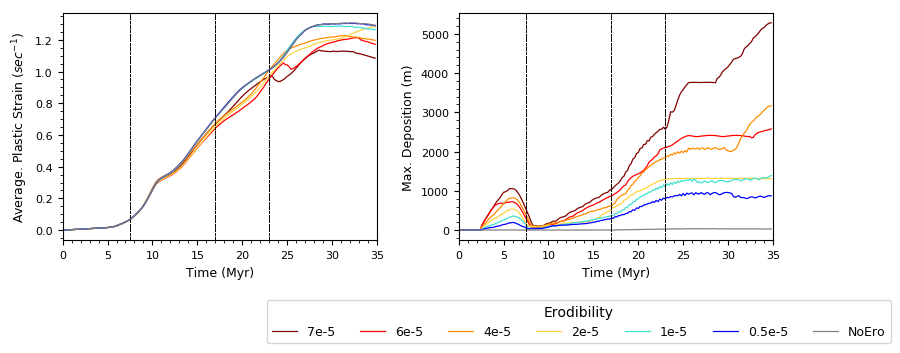

In [58]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
######################################################################################################
Models_ls=["HighEro","HighEro2","MedEro","LowEro","LowEro2","LowEro3","NoEro"]
Models_labs=["7e-5","6e-5","4e-5","2e-5","1e-5","0.5e-5","NoEro"]
#colours=["red","darkmagenta","magenta","blue"]
colourss=["maroon","red","darkorange","#ffd343","turquoise","blue","gray"]
#Models_ls=["HighEro","HighEro2","MedEro2","MedEro","MedEro3","LowEro2","LowEro3","NoEro"]
depth="3km"
maxX=580.
minX=290.
max_timeStep=175
######################################################################################################

fig = plt.figure(figsize=(8,4))

ct2=0
for model in Models_ls:
    
    print(model)
    model_lab=Models_labs[ct2]
    
    #Plastic strain
    pSt1,pSt2,pStdif,total_ts,Cmodel_width_ls=getUw_data(dataFT, model,"NoEro",depth,'projPlasticStrain',
                                                 maxX,minX,total_ts=max_timeStep)
    ## Bdls data. Ero-depo , elevation
    eroDepo1,BdlsSteps1,MinEro1,MaxEro1,Elevation1,MinEl1,MaxEl1=compute_EroDepo_Elev(dataFT,
                                                    model,"eroAvg_evo_",
                                                    maxX,minX,total_ts=max_timeStep)

    #Invert data for looping from the time step 0
    pSt1=pSt1[::-1]
    eroDepo1=eroDepo1[::-1]
    
    ###Arrays with data
    timeCurrents=[]
    maxDepo=[]
    maxEro=[]
    avgPlastic=[]

    for timeStep in range(0,np.shape(pSt1)[0]):
    #
        CurrentTime=timeStep*0.2
        
        current_plasticTime=np.nanmean(pSt1[int(timeStep)])
        current_EroTime=np.nanmin(eroDepo1[int(timeStep)])
        current_DepoTime=np.nanmax(eroDepo1[int(timeStep)])
        
        timeCurrents.append(CurrentTime)
        maxDepo.append(current_DepoTime)
        maxEro.append(-current_EroTime)
        avgPlastic.append(current_plasticTime)
    
    ######################Plotting the max value of every time step
    seed=fig.add_subplot(1,2,1)
    
    seed.plot(timeCurrents,avgPlastic,color=colourss[ct2],label='{0}'.format((model_lab)),
              linewidth=0.9)
    
    seed.set_ylabel(r"Average. Plastic Strain ($sec^{-1}$)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-15)
    
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
    seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=7,
        borderaxespad=0, frameon=True,title="Erodibility")
    
    ######################Plotting the min value of every time step
    seed=fig.add_subplot(1,2,2)
    
    ctt=0
    
    seed.plot(timeCurrents,maxDepo,color=colourss[ct2],label='{0}'.format((model_lab)),
              linewidth=0.9)
    
    #seed.scatter(timeCurrents,minStrain,s=9)
        
    seed.set_ylabel(r"Max. Deposition (m)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-16)
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
    
    ct2=ct2+1  
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.038,wspace=0.26)
    #fig.subplots_adjust(hspace=0.038)
fig  

HighEro
MedEro
LowEro3


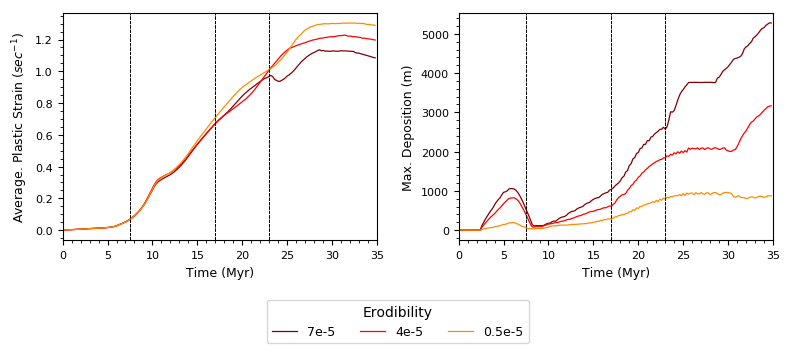

In [193]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
######################################################################################################
Models_ls=["HighEro","MedEro","LowEro3"]
Models_labs=["7e-5","4e-5","0.5e-5"]
#colours=["red","darkmagenta","magenta","blue"]
colourss=["maroon","red","darkorange","#ffd343","turquoise","blue","gray"]
#Models_ls=["HighEro","HighEro2","MedEro2","MedEro","MedEro3","LowEro2","LowEro3","NoEro"]
depth="3km"
maxX=580.
minX=290.
max_timeStep=175
######################################################################################################

fig = plt.figure(figsize=(8,4))

ct2=0
for model in Models_ls:
    
    print(model)
    model_lab=Models_labs[ct2]
    
    #Plastic strain
    pSt1,pSt2,pStdif,total_ts,Cmodel_width_ls=getUw_data(dataFT, model,"NoEro",depth,'projPlasticStrain',
                                                 maxX,minX,total_ts=max_timeStep)
    ## Bdls data. Ero-depo , elevation
    eroDepo1,BdlsSteps1,MinEro1,MaxEro1,Elevation1,MinEl1,MaxEl1=compute_EroDepo_Elev(dataFT,
                                                    model,"eroAvg_evo_",
                                                    maxX,minX,total_ts=max_timeStep)

    #Invert data for looping from the time step 0
    pSt1=pSt1[::-1]
    eroDepo1=eroDepo1[::-1]
    
    ###Arrays with data
    timeCurrents=[]
    maxDepo=[]
    maxEro=[]
    avgPlastic=[]

    for timeStep in range(0,np.shape(pSt1)[0]):
    #
        CurrentTime=timeStep*0.2
        
        current_plasticTime=np.nanmean(pSt1[int(timeStep)])
        current_EroTime=np.nanmin(eroDepo1[int(timeStep)])
        current_DepoTime=np.nanmax(eroDepo1[int(timeStep)])
        
        timeCurrents.append(CurrentTime)
        maxDepo.append(current_DepoTime)
        maxEro.append(-current_EroTime)
        avgPlastic.append(current_plasticTime)
    
    ######################Plotting the max value of every time step
    seed=fig.add_subplot(1,2,1)
    
    seed.plot(timeCurrents,avgPlastic,color=colourss[ct2],label='{0}'.format((model_lab)),
              linewidth=0.9)
    
    seed.set_ylabel(r"Average. Plastic Strain ($sec^{-1}$)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-15)
    
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
    seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=7,
        borderaxespad=0, frameon=True,title="Erodibility")
    
    ######################Plotting the min value of every time step
    seed=fig.add_subplot(1,2,2)
    
    ctt=0
    
    seed.plot(timeCurrents,maxDepo,color=colourss[ct2],label='{0}'.format((model_lab)),
              linewidth=0.9)
    
    #seed.scatter(timeCurrents,minStrain,s=9)
        
    seed.set_ylabel(r"Max. Deposition (m)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-16)
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
    
    ct2=ct2+1  
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.038,wspace=0.26)
    #fig.subplots_adjust(hspace=0.038)
fig  

SHighEro
S2HighEro
HighEro
MedEro
SMedEro
SLowEro2
SLowEro


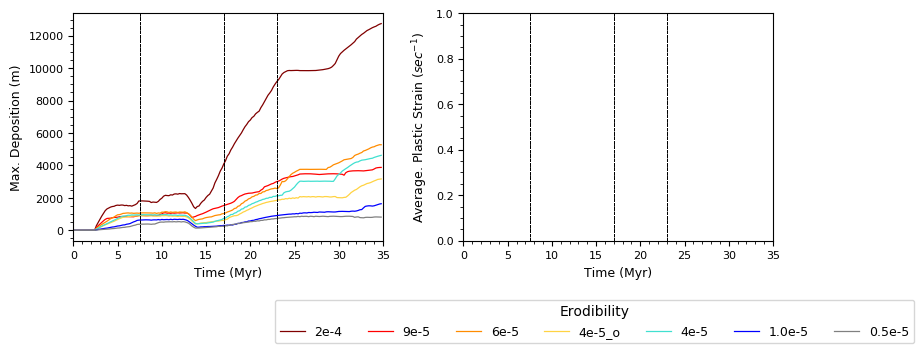

In [416]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
######################################################################################################
Models_ls=["SHighEro","S2HighEro","HighEro","MedEro","SMedEro","SLowEro2","SLowEro"]
Models_labs=["2e-4","9e-5","6e-5","4e-5_o","4e-5","1.0e-5","0.5e-5"]
#colours=["red","darkmagenta","magenta","blue"]
colourss=["maroon","red","darkorange","#ffd343","turquoise","blue","gray"]
#Models_ls=["HighEro","HighEro2","MedEro2","MedEro","MedEro3","LowEro2","LowEro3","NoEro"]
depth="3km"
maxX=580.
minX=180.
max_timeStep=175
######################################################################################################

fig = plt.figure(figsize=(8,4))

ct2=0
for model in Models_ls:
    
    print(model)
    model_lab=Models_labs[ct2]
    
    #Plastic strain
#     pSt1,pSt2,pStdif,total_ts,Cmodel_width_ls=getUw_data(dataFT, model,"NoEro",depth,'projPlasticStrain',
#                                                  maxX,minX,total_ts=max_timeStep)
    ## Bdls data. Ero-depo , elevation
    eroDepo1,BdlsSteps1,MinEro1,MaxEro1,Elevation1,MinEl1,MaxEl1=compute_EroDepo_Elev(dataFT,
                                                    model,"eroAvg_evo_",
                                                    maxX,minX,total_ts=max_timeStep)

    #Invert data for looping from the time step 0
    pSt1=pSt1[::-1]
    eroDepo1=eroDepo1[::-1]
    
    ###Arrays with data
    timeCurrents=[]
    maxDepo=[]
    maxEro=[]
    #avgPlastic=[]

    for timeStep in range(0,np.shape(pSt1)[0]):
    #
        CurrentTime=timeStep*0.2
        
        #current_plasticTime=np.nanmean(pSt1[int(timeStep)])
        current_EroTime=np.nanmin(eroDepo1[int(timeStep)])
        current_DepoTime=np.nanmax(eroDepo1[int(timeStep)])
        
        timeCurrents.append(CurrentTime)
        maxDepo.append(current_DepoTime)
        maxEro.append(-current_EroTime)
        #avgPlastic.append(current_plasticTime)
    
    ######################Plotting the max value of every time step
    seed=fig.add_subplot(1,2,2)
    
    #seed.plot(timeCurrents,avgPlastic,color=colourss[ct2],label='{0}'.format((model_lab)),
             # linewidth=0.9)
    
    seed.set_ylabel(r"Average. Plastic Strain ($sec^{-1}$)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-15)
    
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
#     seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=7,
#         borderaxespad=0, frameon=True,title="Erodibility")
    
    ######################Plotting the min value of every time step
    seed=fig.add_subplot(1,2,1)
    
    ctt=0
    
    seed.plot(timeCurrents,maxDepo,color=colourss[ct2],label='{0}'.format((model_lab)),
              linewidth=0.9)
    
    #seed.scatter(timeCurrents,minStrain,s=9)
        
    seed.set_ylabel(r"Max. Deposition (m)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-16)
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
    seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=7,
         borderaxespad=0, frameon=True,title="Erodibility")
    
    ct2=ct2+1  
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.038,wspace=0.26)
    #fig.subplots_adjust(hspace=0.038)
fig  

SHighEro
S2HighEro
HighEro
MedEro
SMedEro
SLowEro2
SLowEro


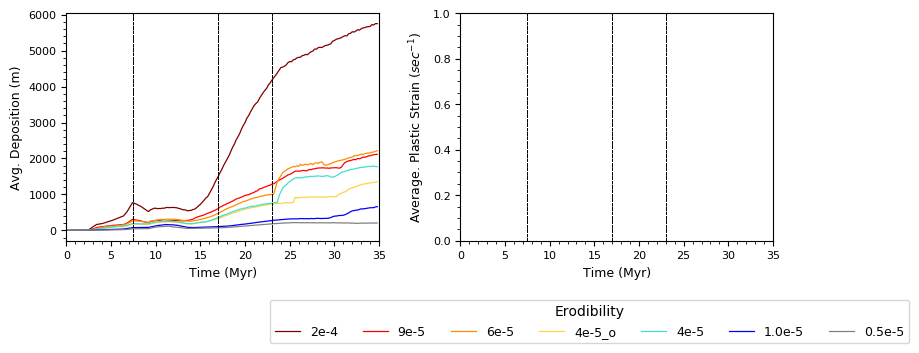

In [417]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
######################################################################################################
Models_ls=["SHighEro","S2HighEro","HighEro","MedEro","SMedEro","SLowEro","LowEro3"]
Models_labs=["2e-4","9e-5","6e-5","4e-5_o","4e-5","0.5e-5","0.5e-5_o"]

Models_ls=["SHighEro","S2HighEro","HighEro","MedEro","SMedEro","SLowEro2","SLowEro"]
Models_labs=["2e-4","9e-5","6e-5","4e-5_o","4e-5","1.0e-5","0.5e-5"]
#colours=["red","darkmagenta","magenta","blue"]
colourss=["maroon","red","darkorange","#ffd343","turquoise","blue","gray"]
#Models_ls=["HighEro","HighEro2","MedEro2","MedEro","MedEro3","LowEro2","LowEro3","NoEro"]
depth="3km"
maxX=580.
minX=180.
max_timeStep=175
######################################################################################################

fig = plt.figure(figsize=(8,4))

ct2=0
for model in Models_ls:
    
    print(model)
    model_lab=Models_labs[ct2]
    
    #Plastic strain
#     pSt1,pSt2,pStdif,total_ts,Cmodel_width_ls=getUw_data(dataFT, model,"NoEro",depth,'projPlasticStrain',
#                                                  maxX,minX,total_ts=max_timeStep)
    ## Bdls data. Ero-depo , elevation
    eroDepo1,BdlsSteps1,MinEro1,MaxEro1,Elevation1,MinEl1,MaxEl1=compute_EroDepo_Elev(dataFT,
                                                    model,"eroAvg_evo_",
                                                    maxX,minX,total_ts=max_timeStep)

    #Invert data for looping from the time step 0
    pSt1=pSt1[::-1]
    eroDepo1=eroDepo1[::-1]
    
    ###Arrays with data
    timeCurrents=[]
    maxDepo=[]
    maxEro=[]
    #avgPlastic=[]

    for timeStep in range(0,np.shape(pSt1)[0]):
    #
        CurrentTime=timeStep*0.2
        
        current_ed=eroDepo1[int(timeStep)]
        
        current_d=current_ed[current_ed > 0]
        current_e=current_ed[current_ed < 0]
        
        
        #current_plasticTime=np.nanmean(pSt1[int(timeStep)])
        current_EroTime=np.nanmean(current_e)
        current_DepoTime=np.nanmean(current_d)
        
        timeCurrents.append(CurrentTime)
        maxDepo.append(current_DepoTime)
        maxEro.append(-current_EroTime)
        #avgPlastic.append(current_plasticTime)
    
    ######################Plotting the max value of every time step
    seed=fig.add_subplot(1,2,2)
    
    #seed.plot(timeCurrents,avgPlastic,color=colourss[ct2],label='{0}'.format((model_lab)),
             # linewidth=0.9)
    
    seed.set_ylabel(r"Average. Plastic Strain ($sec^{-1}$)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-15)
    
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
#     seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=7,
#         borderaxespad=0, frameon=True,title="Erodibility")
    
    ######################Plotting the min value of every time step
    seed=fig.add_subplot(1,2,1)
    
    ctt=0
    
    seed.plot(timeCurrents,maxDepo,color=colourss[ct2],label='{0}'.format((model_lab)),
              linewidth=0.9)
    
    #seed.scatter(timeCurrents,minStrain,s=9)
        
    seed.set_ylabel(r"Avg. Deposition (m)", fontsize=9)
    seed.set_xlabel("Time (Myr)", fontsize=9)
    
    seed.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
    seed.axvline(x=23.,linestyle='--',color="black",lw='0.6')
    # LOG SCALE
    #seed.set_yscale('symlog',linthreshy=1e-16)
    seed.set_xlim(0,35)
    #seed.set_ylim(0,max(maxCurvatures)+20)
    #seed.invert_yaxis()
    seed.tick_params(axis='both', which='major', labelsize=8)
    seed.xaxis.set_minor_locator(AutoMinorLocator())
    seed.yaxis.set_minor_locator(AutoMinorLocator())
    
    seed.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.65, -0.45), ncol=7,
         borderaxespad=0, frameon=True,title="Erodibility")
    
    ct2=ct2+1  
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.038,wspace=0.26)
    #fig.subplots_adjust(hspace=0.038)
fig  

## Correlation plots

In [50]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
dataFT='./Post_processing/Produciton_post_processing_final/'
Filters_uw = {'DevXN':0 , 'DevXP':1 , 'DevYN':2, 'DevYP':3, 'pstrain':4, 'strRate':5}
tec_events=[7.5,17]

### Single plot with plastic strain and deposition/ero interval

## Subplot al plastic strain intervals per specified deposition-intervaL

In [196]:
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
#plot test
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
t_step=0.2 #Myr
############################################
#Data plot
cut_t=0.8
depth="3km"

############################################
UW_thersholds=[(0.01,1.5),(1.5,3.0),(3.0,4.5),(4.5,6)]

Bdls_thres_i=200
Bdls_thres_f=500#positive is deposition, negative is erosion


#num_or_corr="Num"
n_sample=80
uw_corr=Filters_uw["pstrain"]


In [660]:
def multipleCorrPlot(dataFT,models,depth,
                       Xmax,
                       Xmin,
                       Bdls_thres_i,
                         Bdls_thres_f,
                        propFilter=True,
                        propThres_i=uw_thres_i,
                        propThres_f=uw_thres_f,
                        propVar='projPlasticStrain',
                      #propVar='strainRateField',
                     max_time=36., #maximum time used to compute the stages
                     time_interval_cut=cut_t,
                         bdls_source='eroAvg_evo_',
                       Slicing_events=Slicing_events,
                             uw_corr=uw_corr,
                               n_sample=80,
                                num_or_corr="Corr",
                            uw_label='Plastic strain',
                    UW_thersholds=UW_thersholds,
                     Nplots=4,
                    figsize=(7,7),
                     startX=13.):
    
    #print(type(Bdls_thres_i))
    ############################################
    #detect whether is ero or depo
    if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
        #print("float")
        if Bdls_thres_i>0:
            ree="Deposition"
        else:
            ree="Erosion"
        ############################################
    elif isinstance(Bdls_thres_i,list):
        #print("array")
        if Bdls_thres_i[0]>0:
            ree="Deposition"
        else:
            ree="Erosion"
    
    if Nplots==1:
        nrows=1
        ncols=1
        
    else:
        ncols=2
        if Nplots%2==0:
            nrows=int(Nplots/2)
        else:
            nrows=int(Nplots/2)
    
    fig,Axs=plt.subplots(nrows,ncols,figsize=figsize,sharex=True,sharey=True)
    #fig = plt.figure(figsize=(9,5))

    Axs=Axs.flatten()

    Maax=0
    ct=0

    print("sample filter ",n_sample)


    for model in Models_ls:
        
        if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
            cBdls_thres_i=Bdls_thres_i
            cBdls_thres_f=Bdls_thres_f
        elif isinstance(Bdls_thres_i,list):
            cBdls_thres_i=Bdls_thres_i[ct]
            cBdls_thres_f=Bdls_thres_f[ct]
        
        #if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
        print (model+ " {0} - {1} {2} m".format(str(ree),str(cBdls_thres_i),str(cBdls_thres_f)))
        #elif isinstance(Bdls_thres_i,list):
            #print(model)
        
        ct3=0
        for UWTh in UW_thersholds:

            thres_i,thres_f=UWTh

            print(thres_i,thres_f)
            


            #Get correlation and number of samples data
            times,corrs,d_frames,d_framesN=getCorrelationStages_model_all(dataFT,
                                         #"HighEro",
                                          model,
                                         depth,
                                         #580.,370., #area will be replaced by Xmin Xmax
                                          580.,180.,
                                          #580.,100., #Fair enough
                                             cBdls_thres_i,
                                             cBdls_thres_f,
                                            propFilter=True,
                                            propThres_i=thres_i,
                                            propThres_f=thres_f,
                                            propVar=Uw_filter,
                                          #propVar='strainRateField',
                                         max_time=36., #maximum time used to compute the stages
                                         time_interval_cut=cut_t,
                                             bdls_source='eroAvg_evo_',
                                           
                                                                         )

            if num_or_corr=="Corr":

                axs=Axs[ct3]

                for ax in [axs.xaxis, axs.yaxis]:
                        ax.set_major_formatter(ScalarFormatter())

                #seed=ax#[locs1[ct0]]


                #This extracts the selected variable from the correlation 
                x,y=prepareCorrelationPlot(uw_corr, corrs,dt=cut_t) #Plastic strain filter
                #z,m=prepareNdataPlot(4, d_framesN,dt=5) #Plastic strain filter
                z,m=prepareNdataPlot(model,depth, d_framesN,dt=cut_t)
                #Filtering low data correlation
                y=filterbyN(y,m,n_sample)


                axs.axhline(y=0.,linestyle='--',color="black",lw='0.6')
                #axs.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
                axs.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')

    
                if ct3==0:
                    if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
                        axs.set_title("{0} Threshold {1}-{2} m - step {3} - depthStrain = {4}".format(str(ree),
                                        str(Bdls_thres_i),str(Bdls_thres_f),str(cut_t),str(depth)), fontsize=9)
                    elif isinstance(Bdls_thres_i,list):
                        axs.set_title("{0} - step {1} - depthStrain = {2}".format(str(ree),
                                        str(cut_t),str(depth)), fontsize=9)

               #Title
                anchored_title=AnchoredText('Threshold = {0}-{1}'.format(str(thres_i),
                                        str(thres_f)),loc='upper right',pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
                axs.add_artist(anchored_title)


                axs.set_xlim(startX,35.2)
                axs.set_ylim(-1,1)



                if ct3==0 or ct3==2 or ct3==4 or ct3==6:
                    axs.set_ylabel("Correlation",labelpad=2)
                    axs.yaxis.set_minor_locator(AutoMinorLocator())
                
                
                if ct3==len(Axs)-1 or ct3==len(Axs)-2: # 2 3
                    axs.set_xlabel("Time (Ma)",labelpad=2)
                    axs.xaxis.set_minor_locator(AutoMinorLocator())


                axs.plot(x,y,color=colours[ct],label=model,linewidth=0.8) #HighEro

                #axs.set_title("Correlation Plastic strain {0}".format(str(1000)))
                ##LEegnd
                if ct3==len(Axs)-2:
                    axs.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.40, -0.32), ncol=6,
                    borderaxespad=0, frameon=True,title="Erodibility")

            ################################################################################################
            #NUMBER OF VALUES PLOT
            elif num_or_corr=="Num":

                axs=Axs[ct3]

                #GEt number of values

                axs.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
        #         axs.set_title("Filter by Norm {0}-Threshold = {1}-{2}".format(str(uw_label),str(uw_thres_i),
        #                                                                      str(uw_thres_f)))


                axs.set_xticks([0,5,10,15,20,25,30,35])


                z,m=prepareNdataPlot(model,depth, d_framesN,dt=cut_t)
                
                if ct3==0 or ct3==2 or ct3==4 or ct3==6:
                    axs.set_ylabel("Number of Samples",labelpad=2)
                    axs.yaxis.set_minor_locator(AutoMinorLocator())

                if ct3==len(Axs)-1 or ct3==len(Axs)-2:
                    axs.set_xlabel("Time (Ma)",labelpad=2)
                    axs.xaxis.set_minor_locator(AutoMinorLocator())

                axs.axhline(y=0.,linestyle='--',color="black",lw='0.6')
                axs.plot(z,m,color=colours[ct],label=model,linewidth=0.8)

                maax=max(m)
                if ct==0:
                    Maax=maax
                if maax>Maax:
                    Maax=maax

                axs.set_ylim(0,Maax+Maax*0.1)
                axs.set_xlim(13,35.2)
                #axs.set_ylim(-1,1)

                #Title
                anchored_title=AnchoredText('Threshold = {0}-{1}'.format(str(thres_i),str(thres_f)),
                                            loc='upper right',
                                            pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
                axs.add_artist(anchored_title)

                #Legend
                if ct3==len(Axs)-2:
                    axs.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.40, -0.32), ncol=6,
                    borderaxespad=0, frameon=True,title="Erodibility")
            ################################################################################################
            ct3=ct3+1

        ct=ct+1

    fig.tight_layout()
    fig.subplots_adjust(wspace=0.05,hspace=0.05)
    #fig
    return fig

## Function to extract average correlation in time windows of an specific model

In [827]:
def sliceCorrelationAvg_singleModel(dataFT,model,depth,
                       Xmax,
                       Xmin,
                       Bdls_thres_i,
                         Bdls_thres_f,
                        propFilter,
                        propThres_i,
                        propThres_f,
                        propVar,
                      #propVar='strainRateField',
                     max_time, #maximum time used to compute the stages
                     time_interval_cut,
                         bdls_source,
                       Slicing_events,
                        n_sample,
                        correlation= "pearson"):
    
    uw_corr=Filters_uw["pstrain"]
    
    #Loop in all the models using the selected parameters
    #for model in Models_ls:
    #print (model)
    times,corrs,d_frames,d_framesN=getCorrelationStages_model_all(dataFT,
                             #"HighEro",
                              model,
                             depth,
                             #580.,370., #area will be replaced by Xmin Xmax
                              Xmax,Xmin,
                              #580.,100., #Fair enough
                                 Bdls_thres_i,
                                 Bdls_thres_f,
                                propFilter,
                                propThres_i,
                                propThres_f,
                                propVar,
                              #propVar='strainRateField',
                             max_time=36., #maximum time used to compute the stages
                            correlation=correlation,
                             time_interval_cut=cut_t,
                                 bdls_source='eroAvg_evo_')

    ##########################################################################################
    #This extracts the selected variable from the correlation 
    ts,corr=prepareCorrelationPlot(uw_corr, corrs,dt=cut_t) #Plastic strain filter
    #z,m=prepareNdataPlot(4, d_framesN,dt=5) #Plastic strain filter
    z,m=prepareNdataPlot(model,depth, d_framesN,dt=cut_t)
    #Filtering low data correlation

    corr=filterbyN(corr,m,n_sample,nans=True)
    
    c_numberS=m
    ##########################################################################################
    #print(ts,corr)
    #print(ts,corr)
    
    avgs_Corr=[]
    slice_times=[]
    Ns_in_avg=[]

    #Slice using the times variable
    for event in Slicing_events:
        init_time=float(event[0])
        final_time=float(event[1])
        
        #print(corrs)
        
        #print(init_time,final_time)
        #print(corr)
        #print(ts[:]>=init_time)
        #print(ts[:]<=final_time)
        
        sliceIndexes=np.where(np.logical_and(ts[:]>=init_time,ts[:]<=final_time))[0]
        
        #ts,corr
        #print(sliceIndexes)
        
        try:
            corrs_sliced=corr[sliceIndexes]
            
            ##WHere correlation is not possible. because number of data is below threshold, correlation is nan
            avg_current=np.nanmean(corrs_sliced)
            sum_avgs_current=np.sum(c_numberS[sliceIndexes])
            
        except TypeError:
            avg_current=np.nan
            
        

        avgs_Corr.append(avg_current)
        slice_times.append(event)
        Ns_in_avg.append(sum_avgs_current)
    
    return slice_times,avgs_Corr,Ns_in_avg

In [823]:
np.sum([1,2,3])

6

## Number of data - Plot

In [890]:
UW_thershold=(0.1,1.5)

def multipleCorrPlot_ns(dataFT,models,depth,
                       Xmax,
                       Xmin,
                        #####################
                        Bdls_thresholds,
                        ##################
                       #Bdls_thres_i,
                         #Bdls_thres_f,
                        propFilter=True,
                        propThres_i=uw_thres_i,
                        propThres_f=uw_thres_f,
                        propVar='projPlasticStrain',
                      #propVar='strainRateField',
                     max_time=36., #maximum time used to compute the stages
                     time_interval_cut=cut_t,
                         bdls_source='eroAvg_evo_',
                       Slicing_events=Slicing_events,
                             uw_corr=uw_corr,
                               n_sample=80,
                                num_or_corr="Corr",
                            uw_label='Plastic strain',
                     Nplots=4,
                    figsize=(7,7),
                     startX=13.):
    
    #print(type(Bdls_thres_i))
    ############################################
    #detect whether is ero or depo
#     if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
#         #print("float")
#         if Bdls_thres_i>0:
#             ree="Deposition"
#         else:
#             ree="Erosion"
#         ############################################
#     elif isinstance(Bdls_thres_i,list):
#         #print("array")
#         if Bdls_thres_i[0]>0:
#             ree="Deposition"
#         else:
#             ree="Erosion"
    
    if Nplots==1:
        nrows=1
        ncols=1
        
    else:
        ncols=2
        if Nplots%2==0:
            nrows=int(Nplots/2)
        else:
            nrows=int(Nplots/2)
    
    fig,Axs=plt.subplots(nrows,ncols,figsize=figsize,sharex=True,sharey=True)
    #fig = plt.figure(figsize=(9,5))

    Axs=Axs.flatten()

    Maax=0
    ct=0

    print("sample filter ",n_sample)

    titt=0
    for model in Models_ls:
        

        ct3=0
        
        
        #for UWTh in UW_thersholds:
        #Change this one to the bdls intervals
        for BDsTh in Bdls_thresholds:
            Bdls_thres_i,Bdls_thres_f=BDsTh
            
            if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
                cBdls_thres_i=Bdls_thres_i
                cBdls_thres_f=Bdls_thres_f
            elif isinstance(Bdls_thres_i,list):
                cBdls_thres_i=Bdls_thres_i[ct]
                cBdls_thres_f=Bdls_thres_f[ct]
            
            
            if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
                #print("float")
                if Bdls_thres_i>0:
                    ree="Deposition"
                else:
                    ree="Erosion"
                ############################################
            elif isinstance(Bdls_thres_i,list):
                #print("array")
                if Bdls_thres_i[0]>0:
                    ree="Deposition"
                else:
                    ree="Erosion"
            
            #if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
            #print (model+ " {0} - {1} {2} m".format(str(ree),str(cBdls_thres_i),str(cBdls_thres_f)))
            #elif isinstance(Bdls_thres_i,list):
            #print(model)
        
            
            #thres_i,thres_f=UWTh
            thres_i,thres_f= propThres_i, propThres_f

            #print(thres_i,thres_f)
            print(cBdls_thres_i,cBdls_thres_f)


            #Get correlation and number of samples data
            times,corrs,d_frames,d_framesN=getCorrelationStages_model_all(dataFT,
                                         #"HighEro",
                                          model,
                                         depth,
                                         #580.,370., #area will be replaced by Xmin Xmax
                                          580.,180.,
                                          #580.,100., #Fair enough
                                         ########################
                                        #Change these two interatively
                                             cBdls_thres_i,
                                             cBdls_thres_f,
                                        ###########################
                                            propFilter=True,
                                            propThres_i=thres_i,
                                            propThres_f=thres_f,
                                            propVar=Uw_filter,
                                          #propVar='strainRateField',
                                         max_time=36., #maximum time used to compute the stages
                                         time_interval_cut=cut_t,
                                             bdls_source='eroAvg_evo_',
                                           
                                                                         )

            if num_or_corr=="Corr":

                axs=Axs[ct3]

                for ax in [axs.xaxis, axs.yaxis]:
                        ax.set_major_formatter(ScalarFormatter())

                #seed=ax#[locs1[ct0]]


                #This extracts the selected variable from the correlation 
                x,y=prepareCorrelationPlot(uw_corr, corrs,dt=cut_t) #Plastic strain filter
                #z,m=prepareNdataPlot(4, d_framesN,dt=5) #Plastic strain filter
                z,m=prepareNdataPlot(model,depth, d_framesN,dt=cut_t)
                #Filtering low data correlation
                y=filterbyN(y,m,n_sample)


                axs.axhline(y=0.,linestyle='--',color="black",lw='0.6')
                #axs.axvline(x=tec_events[0],linestyle='--',color="black",lw='0.6')
                axs.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')

    
                if ct3==0:
                    if isinstance(Bdls_thres_i,float) or isinstance(Bdls_thres_i,int):
                        axs.set_title("{0} Threshold {1}-{2} m - step {3} - depthStrain = {4}".format(str(ree),
                                        str(Bdls_thres_i),str(Bdls_thres_f),str(cut_t),str(depth)), fontsize=9)
                    elif isinstance(Bdls_thres_i,list):
                        axs.set_title("{0} - step {1} - depthStrain = {2}".format(str(ree),
                                        str(cut_t),str(depth)), fontsize=9)

               #Title
                anchored_title=AnchoredText('Threshold = {0}-{1} m'.format(str(cBdls_thres_i),
                                        str(cBdls_thres_f)),loc='upper right',pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
                axs.add_artist(anchored_title)


                axs.set_xlim(startX,35.2)
                axs.set_ylim(-1,1)



                if ct3==0 or ct3==2 or ct3==4 or ct3==6:
                    axs.set_ylabel("Correlation",labelpad=2)
                    axs.yaxis.set_minor_locator(AutoMinorLocator())
                
                
                if ct3==len(Axs)-1 or ct3==len(Axs)-2: # 2 3
                    axs.set_xlabel("Time (Ma)",labelpad=2)
                    axs.xaxis.set_minor_locator(AutoMinorLocator())


                axs.plot(x,y,color=colours[ct],label=model,linewidth=0.8) #HighEro

                #axs.set_title("Correlation Plastic strain {0}".format(str(1000)))
                ##LEegnd
                if ct3==len(Axs)-2:
                    axs.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.40, -0.32), ncol=6,
                    borderaxespad=0, frameon=True,title="Erodibility")

            ################################################################################################
            #NUMBER OF VALUES PLOT
            elif num_or_corr=="Num":
                #print("check num")
                axs=Axs[ct3]

                #GEt number of values

                axs.axvline(x=tec_events[1],linestyle='--',color="black",lw='0.6')
                
                if titt==0:
                    axs.set_title("Filter by Plastic Strain {0}-Threshold = {1}-{2}".format(str(uw_label),
                                                                    str(thres_i),
                                                            str(thres_f)))
                    titt=titt+1


                axs.set_xticks([0,5,10,15,20,25,30,35])


                z,m=prepareNdataPlot(model,depth, d_framesN,dt=cut_t)
                
                if ct3==0 or ct3==2 or ct3==4 or ct3==6:
                    axs.set_ylabel("Number of Samples",labelpad=2)
                    axs.yaxis.set_minor_locator(AutoMinorLocator())

                if ct3==len(Axs)-1 or ct3==len(Axs)-2:
                    axs.set_xlabel("Time (Ma)",labelpad=2)
                    axs.xaxis.set_minor_locator(AutoMinorLocator())

                axs.axhline(y=0.,linestyle='--',color="black",lw='0.6')
                axs.plot(z,m,color=colours[ct],label=model,linewidth=0.8)

                maax=max(m)
                if ct==0:
                    Maax=maax
                if maax>Maax:
                    Maax=maax

                #axs.set_ylim(0,Maax+Maax*0.1)
                axs.set_xlim(startX,35.2)
                #axs.set_ylim(-1,1)

                #Title
                #if titt==0:
                anchored_title=AnchoredText(ree+' = {0}-{1} m'.format(str(cBdls_thres_i),
                                                    str(cBdls_thres_f)),
                                            loc='upper right',
                                            pad=0.3,borderpad=0.3,frameon=False,prop=dict(size=9))
                axs.add_artist(anchored_title)

                    #titt=titt+1

                #Legend
                if ct3==len(Axs)-2:
                    axs.legend(loc='lower left', prop={'size': 9},bbox_to_anchor= (0.40, -0.32), ncol=6,
                    borderaxespad=0, frameon=True,title="Erodibility")
            ################################################################################################
            ct3=ct3+1

        ct=ct+1

    fig.tight_layout()
    fig.subplots_adjust(wspace=0.05,hspace=0.05)
    #fig
    return fig

sample filter  1
200 1000
200 1500
1000 7500
1500 7500
200 1000
200 1500
1000 7500
1500 7500
200 1000
200 1500
1000 7500
1500 7500


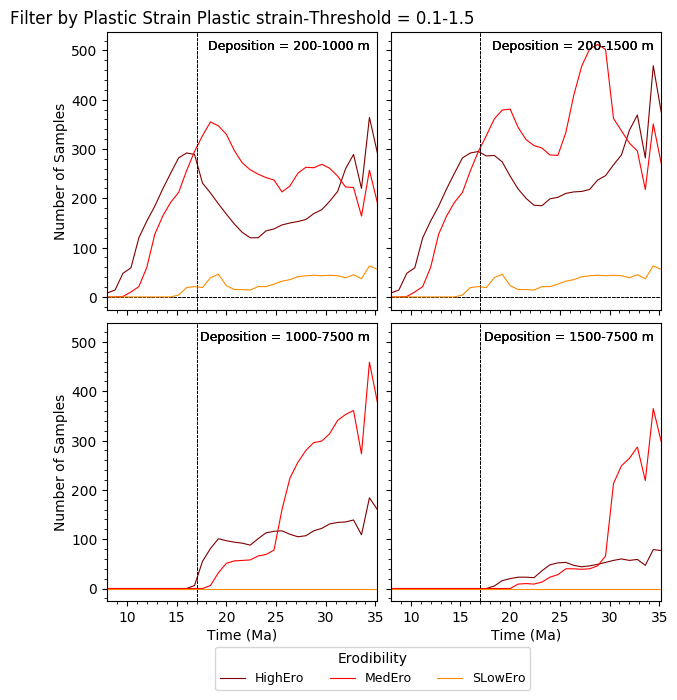

In [891]:
###### UW_thersholds=[(0.01,1.5),(1.5,3.0),(3.0,4.5),(4.5,6)]

uw_thres_i=0.1
uw_thres_f=1.5

Bdls_thres=[(200,1000),(200,1500),(1000,11500),(1500,11500)]

Bdls_thres=[(200,1000),(200,1500),(1000,7500),(1500,7500)]

Models_ls=["HighEro","MedEro","SLowEro"]

fig=multipleCorrPlot_ns(dataFT,Models_ls,
                         "6km",
                       Xmax,
                       Xmin,
                       Bdls_thresholds=Bdls_thres,
                        propFilter=True,
                        propThres_i=uw_thres_i,
                        propThres_f=uw_thres_f,
                        propVar=Uw_filter,
                      #propVar='strainRateField',
                     max_time=36., #maximum time used to compute the stages
                     time_interval_cut=cut_t,
                         bdls_source='eroAvg_evo_',
                     #UW_thershold=UW_thershold,
                       Slicing_events=Slicing_events,
                               #n_sample=60,
                                 n_sample=1,
                        num_or_corr="Num",
                            Nplots=4,
                        figsize=(7, 7),
                       startX=8.)

fig

sample filter  1
200 1000
200 1500
1000 7500
1500 7500
200 1000
200 1500
1000 7500
1500 7500
200 1000
200 1500
1000 7500
1500 7500


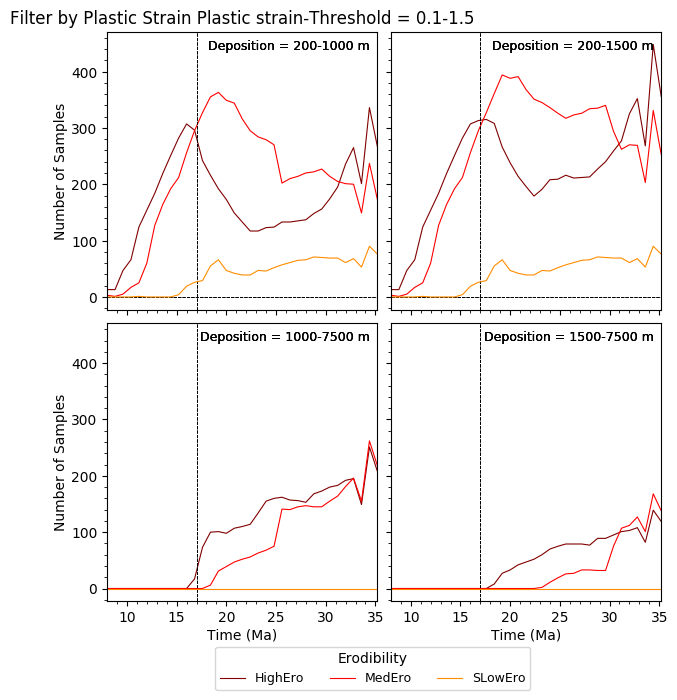

In [892]:

#UW_thersholds=[(0.01,1.5),(1.5,3.0),(3.0,4.5),(4.5,6)]
uw_thres_i=0.1
uw_thres_f=1.5

Bdls_thres=[(200,1000),(200,1500),(1000,11500),(1500,11500)]

Bdls_thres=[(200,1000),(200,1500),(1000,7500),(1500,7500)]

Models_ls=["HighEro","MedEro","SLowEro"]

fig=multipleCorrPlot_ns(dataFT,Models_ls,
                         "4_5km",
                       Xmax,
                       Xmin,
                       Bdls_thresholds=Bdls_thres,
                        propFilter=True,
                        propThres_i=uw_thres_i,
                        propThres_f=uw_thres_f,
                        propVar=Uw_filter,
                      #propVar='strainRateField',
                     max_time=36., #maximum time used to compute the stages
                     time_interval_cut=cut_t,
                         bdls_source='eroAvg_evo_',
                     #UW_thershold=UW_thershold,
                       Slicing_events=Slicing_events,
                               #n_sample=60,
                                 n_sample=1,
                        num_or_corr="Num",
                            Nplots=4,
                        figsize=(7, 7),
                       startX=8.)

fig


sample filter  1
200 1000
200 1500
1000 7500
1500 7500
200 1000
200 1500
1000 7500
1500 7500
200 1000
200 1500
1000 7500
1500 7500


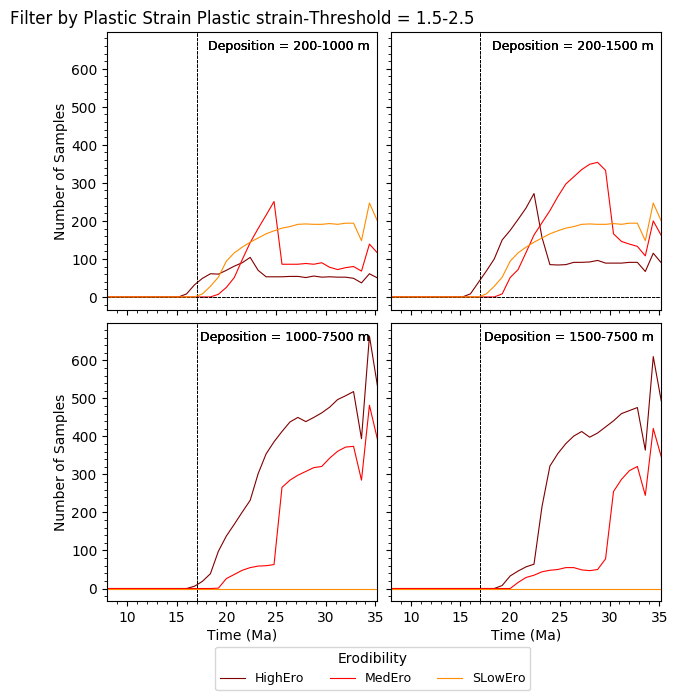

In [895]:
#UW_thersholds=[(0.01,1.5),(1.5,3.0),(3.0,4.5),(4.5,6)]
uw_thres_i=1.5
uw_thres_f=2.5

Bdls_thres=[(200,1000),(200,1500),(1000,7500),(1500,7500)]

Models_ls=["HighEro","MedEro","SLowEro"]

fig=multipleCorrPlot_ns(dataFT,Models_ls,
                         "4_5km",
                       Xmax,
                       Xmin,
                       Bdls_thresholds=Bdls_thres,
                        propFilter=True,
                        propThres_i=uw_thres_i,
                        propThres_f=uw_thres_f,
                        propVar=Uw_filter,
                      #propVar='strainRateField',
                     max_time=36., #maximum time used to compute the stages
                     time_interval_cut=cut_t,
                         bdls_source='eroAvg_evo_',
                     #UW_thershold=UW_thershold,
                       Slicing_events=Slicing_events,
                               #n_sample=60,
                                 n_sample=1,
                        num_or_corr="Num",
                            Nplots=4,
                        figsize=(7, 7),
                       startX=8.)

fig

### Low Sedimentation, Low plastic strain 

In [825]:
corrs=["pearson","spearman","kendall"]

Correlation_all="spearman"

In [829]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=1500#positive is deposition, negative is erosion
# uw_thres_i=0.01
# uw_thres_f=3.0#

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Bdls_s=[(200,3500),(200,2500),(200,1500),(200,1000)]

Bdls_s=[(200,1500),(200,1500),(200,1500),(200,1500)]

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs,avg_Ns=sliceCorrelationAvg_singleModel(dataFT,model,"3km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                            correlation=Correlation_all)
    print(times,np.round(avg_corrs,3),avg_Ns)

S3HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [ 0.055  0.064  0.101 -0.094] [1351.0, 1638.0, 1128.0, 1558.0]
HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.347 0.466 0.46  0.455] [723.0, 2114.0, 1740.0, 2981.0]
MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.284 0.15  0.298 0.284] [367.0, 1854.0, 2799.0, 2848.0]
SLowEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.076  0.182  0.466] [0.0, 278.0, 812.0, 1255.0]


In [830]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=1500#positive is deposition, negative is erosion
# uw_thres_i=0.01
# uw_thres_f=3.0#

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(200,3500),(200,2500),(200,1500),(200,1000)]

Bdls_s=[(200,1500),(200,1500),(200,1500),(200,1500)]

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs,avg_Ns=sliceCorrelationAvg_singleModel(dataFT,model,"4_5km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                               correlation=Correlation_all)
    print(times,np.round(avg_corrs,3),avg_Ns)

S3HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [ 0.149  0.252 -0.358 -0.353] [1389.0, 1780.0, 1130.0, 1530.0]
HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.436 0.68  0.601 0.503] [729.0, 1789.0, 1403.0, 2609.0]
S4MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.276 0.352 0.228] [70.0, 1382.0, 2353.0, 3954.0]
MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.005 0.108 0.489 0.397] [370.0, 1846.0, 2346.0, 2550.0]


In [831]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=1500#positive is deposition, negative is erosion
# uw_thres_i=0.01
# uw_thres_f=3.0#

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(200,3500),(200,2500),(200,1500),(200,1000)]

Bdls_s=[(200,1500),(200,1500),(200,1500),(200,1500)]

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs,avg_Ns=sliceCorrelationAvg_singleModel(dataFT,model,"6km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                               correlation=Correlation_all)
    print(times,np.round(avg_corrs,3),avg_Ns)

S3HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [ 0.26   0.305 -0.228 -0.175] [1387.0, 1797.0, 1292.0, 1663.0]
HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.517 0.688 0.547 0.451] [724.0, 1711.0, 1392.0, 2712.0]
S4MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.292 0.392 0.319] [69.0, 1377.0, 2243.0, 4053.0]
MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [-0.197  0.043  0.342  0.253] [367.0, 1831.0, 2227.0, 3300.0]


### Low Sedimentation, High plastic strain 

In [835]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=1500#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

#Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(200,3500),(200,2500),(200,1500),(200,1000)]

Bdls_s=[(200,1500),(200,1500),(200,1500),(200,1500)]

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs,avg_Ns=sliceCorrelationAvg_singleModel(dataFT,model,"3km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                               correlation=Correlation_all)
    print(times,np.round(avg_corrs,3),avg_Ns)

S3HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [nan nan nan nan] [0.0, 70.0, 126.0, 166.0]
HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.045   nan] [0.0, 24.0, 676.0, 436.0]
MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.422  0.097] [0.0, 0.0, 1127.0, 1626.0]
SLowEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.476 -0.8  ] [0.0, 10.0, 668.0, 1103.0]


In [833]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=1500#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(200,3500),(200,2500),(200,1500),(200,1000)]

Bdls_s=[(200,1500),(200,1500),(200,1500),(200,1500)]

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs,avg_Ns=sliceCorrelationAvg_singleModel(dataFT,model,"4_5km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                               correlation=Correlation_all)
    print(times,np.round(avg_corrs,3),avg_Ns)

S3HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [nan nan nan nan] [0.0, 126.0, 303.0, 278.0]
HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.127  0.205  0.258] [0.0, 363.0, 1013.0, 819.0]
S4MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.018 0.579] [0.0, 49.0, 2062.0, 1301.0]
MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.095  0.012] [0.0, 8.0, 1580.0, 1924.0]


In [834]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=1500#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(200,3500),(200,2500),(200,1500),(200,1000)]

Bdls_s=[(200,1500),(200,1500),(200,1500),(200,1500)]

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs,avg_Ns=sliceCorrelationAvg_singleModel(dataFT,model,"6km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                                   
                           correlation=Correlation_all)
    print(times,np.round(avg_corrs,3),avg_Ns)

S3HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [nan nan nan nan] [0.0, 109.0, 141.0, 145.0]
HighEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.289 0.24  0.148] [0.0, 441.0, 1024.0, 716.0]
S4MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.027  0.368] [0.0, 54.0, 2172.0, 1202.0]
MedEro 200 1500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.035 -0.145] [0.0, 23.0, 1699.0, 1174.0]


### Midd Sedimentation, Low plastic strain 

In [822]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

Bdls_s=[(200,12500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"3km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             #Bdls_thres_f,
                             14000,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 200 12500
[(8, 14), (15, 20), (21, 27), (28, 35)] [ 0.055 -0.002  0.336  0.297]
HighEro 200 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.347 0.446 0.479 0.579]
S4MedEro 200 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.252 0.473 0.353]
MedEro 200 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.284 0.15  0.433 0.414]


In [820]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

Bdls_s=[(200,12500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"4_5km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                    correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 200 12500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.149 0.217 0.251 0.132]
HighEro 200 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.436 0.673 0.594 0.628]
S4MedEro 200 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.276 0.352 0.259]
MedEro 200 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.005 0.108 0.538 0.587]


In [821]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

Bdls_s=[(200,12500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"6km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 200 12500
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.26  0.309 0.332 0.24 ]
HighEro 200 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [0.517 0.689 0.574 0.551]
S4MedEro 200 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.292 0.392 0.319]
MedEro 200 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [-0.197  0.043  0.421  0.378]


### Midd Sedimentation, High plastic strain 

In [803]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"3km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 200 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.666 -0.018]
HighEro 200 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.059  0.559]
S4MedEro 200 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.135  0.233]
MedEro 200 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.369 -0.09 ]


In [804]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"4_5km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                    correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 200 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.09   0.172  0.512]
HighEro 200 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.082  0.177  0.513]
S4MedEro 200 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.046  0.443]
MedEro 200 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.22  -0.081]


In [805]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=200
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"6km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 200 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.152 0.177 0.511]
HighEro 200 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan 0.166 0.236 0.088]
S4MedEro 200 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.003  0.036]
MedEro 200 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.061 -0.065]


### High Sedimentation, High plastic strain 

In [806]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=1500
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

#Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"3km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 1500 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [nan nan nan 0.3]
HighEro 1500 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan -0.036  0.52 ]
S4MedEro 1500 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan   nan 0.152]
MedEro 1500 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan    nan -0.124]


In [807]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=2500
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

#Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"4_5km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                    correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 1500 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.193 0.576]
HighEro 1500 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.091 0.461]
S4MedEro 1500 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [ nan  nan  nan 0.23]
MedEro 1500 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan   nan 0.169]


In [808]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=2500
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=3
# uw_thres_f=6#>3 does not really matter when ero is 500

uw_thres_i=1.5
uw_thres_f=3.0#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

#Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"6km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 1500 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.135 0.502]
HighEro 1500 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan  0.079 -0.122]
S4MedEro 1500 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan    nan -0.237]
MedEro 1500 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan   nan 0.022]


### High Sedimentation, Low plastic strain 

In [812]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=2500
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=0.01
# uw_thres_f=3.0#>3 does not really matter when ero is 500

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

#Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"3km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 1500 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.12   0.248  0.158]
HighEro 1500 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.045 0.153]
S4MedEro 1500 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan   nan 0.133]
MedEro 1500 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.608 0.215]


In [813]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=2500
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=0.01
# uw_thres_f=3.0#>3 does not really matter when ero is 500

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

#Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"4_5km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 1500 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.121  0.122  0.108]
HighEro 1500 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan 0.313 0.497]
S4MedEro 1500 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [nan nan nan nan]
MedEro 1500 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan   nan -0.07]


In [814]:
############################################
Slicing_events=[(8,14),(15,20),(21,27),(28,35)] #In Ma
############################################
#Data plot
Bdls_thres_i=2500
Bdls_thres_f=14000#positive is deposition, negative is erosion
# uw_thres_i=0.01
# uw_thres_f=3.0#>3 does not really matter when ero is 500

uw_thres_i=0.1
uw_thres_f=1.5#

Uw_filter='projPlasticStrain'
############################################
Xmax=580.
Xmin=200.
cut_t=0.8
############################################
model="HighEro"
Models_ls=["SHighEro","HighEro","MedEro","LowEro3"]

Models_ls=["S3HighEro","HighEro","MedEro","SLowEro"]

Models_ls=["S3HighEro","HighEro","S4MedEro","MedEro","SLowEro"]

Bdls_s=[(3500,10500),(2500,6000),(1500,3500),(1000,2000)]

Bdls_s=[(1500,10500),(1500,6000),(1500,3500),(1500,3000)]

#Bdls_s=[(200,10500),(200,6000),(200,3500),(200,3000)] #200- to max

for model,Bdls_lims in zip (Models_ls,Bdls_s):
    
    Bdls_thres_i=Bdls_lims[0]
    Bdls_thres_f=Bdls_lims[1]
    
    print(model,Bdls_thres_i,Bdls_thres_f)
    
    times,avg_corrs=sliceCorrelationAvg_singleModel(dataFT,model,"6km",
                           Xmax,
                           Xmin,
                           Bdls_thres_i,
                             Bdls_thres_f,
                            propFilter=True,
                            propThres_i=uw_thres_i,
                            propThres_f=uw_thres_f,
                            propVar=Uw_filter,
                          #propVar='strainRateField',
                         max_time=36., #maximum time used to compute the stages
                         time_interval_cut=cut_t,
                             bdls_source='eroAvg_evo_',
                           Slicing_events=Slicing_events,
                                   n_sample=60,
                                   correlation=Correlation_all)
    print(times,np.round(avg_corrs,3))

S3HighEro 1500 10500
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan -0.135  0.249  0.166]
HighEro 1500 6000
[(8, 14), (15, 20), (21, 27), (28, 35)] [  nan   nan   nan 0.758]
S4MedEro 1500 3500
[(8, 14), (15, 20), (21, 27), (28, 35)] [nan nan nan nan]
MedEro 1500 3000
[(8, 14), (15, 20), (21, 27), (28, 35)] [   nan    nan    nan -0.001]
